## 1. 경로 / 설정

In [5]:
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# manifest 로드
manifest_path = DATA_RAW / "metadata" / "manifest.json"
if manifest_path.exists():
    with open(manifest_path, encoding="utf-8") as f:
        manifest = json.load(f)
    meta_lookup = {m["filename"]: m for m in manifest if m.get("downloaded")}
else:
    meta_lookup = {}

pdf_paths = sorted((DATA_RAW / "pdf").rglob("*.pdf"))
# pdf_paths = sorted(DATA_RAW.rglob("*.pdf"))
print(f"분석 대상 PDF: {len(pdf_paths)}개")
for p in pdf_paths:
    print(f"  {p.parent.name}/{p.name}")

분석 대상 PDF: 3개
  pdf/1Q26_Naver_Earnings_KOR_vF.pdf
  pdf/2026 1Q PT K_(최종).pdf
  pdf/berkshirehathaway_26_first_quarter.pdf


## 2. 문서별 기본 정보 수집
PyMuPDF로 페이지 수, 파일 크기, 표/이미지 개수를 한 번에 추출한다.

In [6]:
import fitz  # PyMuPDF
import pandas as pd


def inspect_pdf(pdf_path: Path) -> dict:
    """PDF 1개의 구조적 정보 추출."""
    doc = fitz.open(str(pdf_path))

    total_pages = len(doc)
    total_chars = 0
    total_images = 0
    total_tables = 0
    pages_with_text = 0

    for page in doc:
        text = page.get_text()
        if text.strip():
            pages_with_text += 1
        total_chars += len(text)
        total_images += len(page.get_images())
        # PyMuPDF의 find_tables는 1.23+ 버전 필요
        try:
            tables = page.find_tables()
            total_tables += len(tables.tables) if hasattr(tables, "tables") else 0
        except Exception:
            pass

    doc.close()

    extra = meta_lookup.get(pdf_path.name, {})
    return {
        "filename": pdf_path.name,
        "org": extra.get("org", pdf_path.parent.name),
        "language": extra.get("language", "?"),
        "doc_type": extra.get("doc_type", "?"), # manifest.json에 적어둔 문서 분류. 자동 추출한 값 X.
        "file_size_mb": round(pdf_path.stat().st_size / 1024 / 1024, 2), # PDF 파일 자체의 크기 텍스트 양과 꼭 비례하지는 않지만, 그래도 일종의 간접 지표가 될 수 있다. ex. 텍스트 중심의 PDF, 이미지/스캔/차트 중심 PDF/파싱/임베딩/저장 비용이 커질 수 있는 PDF 등. 진단 표에 넣을 때는 1) 파일 크기 범주(0-1MB, 1-10MB, 10MB 이상)로 구분해서 넣어도 좋을 듯.
        "pages": total_pages,
        "pages_with_text": pages_with_text, # PyMuPDF가 page.get_text()로 텍스트를 뽑았을 때, 빈 문자열이 아닌 페이지 수. 이미지로만 된 페이지 제외.
        "total_chars": total_chars, # 문자 수 글자, len(text) : 공백, 줄바꿈, 숫자, 기호까지 포함한 문자열 길이예요. 단어 수 아님.
        "avg_chars_per_page": round(total_chars / max(total_pages, 1)),
        "images": total_images,
        "tables": total_tables,
    }

# word_count = len(text.split())
# 한국어는 띄어쓰기 기준 단어 수가 애매해서, RAG에서는 보통 char 수나 token 수를 더 많이 보기도 함. 토큰 수는 tiktoken으로 계산할 예정.

rows = []
for p in pdf_paths:
    try:
        rows.append(inspect_pdf(p))
        print(f"  OK   {p.name}")
    except Exception as e:
        print(f"  FAIL {p.name}: {e}")

df_basic = pd.DataFrame(rows)
df_basic

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
  OK   1Q26_Naver_Earnings_KOR_vF.pdf
  OK   2026 1Q PT K_(최종).pdf
  OK   berkshirehathaway_26_first_quarter.pdf


,filename,org,language,doc_type,file_size_mb,pages,pages_with_text,total_chars,avg_chars_per_page,images,tables
0,1Q26_Naver_Earnings_KOR_vF.pdf,NAVER,ko,earnings_report,0.22,12,12,6442,537,13,15
1,2026 1Q PT K_(최종).pdf,Kakao,ko,earnings_presentation,0.79,11,10,4749,432,31,7
2,berkshirehathaway_26_first_quarter.pdf,Berkshire Hathaway,en,quarterly_report,1.18,53,53,172901,3262,0,330


In [7]:
# 무엇을 이미지로 파악하고 테이블로 파악하는 지 알기 위한 코드
# 이미지/테이블 위치 분석
def region_label(rect, page_rect):
    x_mid = (rect.x0 + rect.x1) / 2
    y_mid = (rect.y0 + rect.y1) / 2

    h_pos = "left" if x_mid < page_rect.width / 3 else "center" if x_mid < page_rect.width * 2 / 3 else "right"
    v_pos = "top" if y_mid < page_rect.height / 3 else "middle" if y_mid < page_rect.height * 2 / 3 else "bottom"

    return f"{v_pos}-{h_pos}"


def inspect_images_by_page(pdf_path: Path) -> pd.DataFrame:
    doc = fitz.open(str(pdf_path))
    rows = []

    for page_idx, page in enumerate(doc):
        page_rect = page.rect

        for img_idx, img in enumerate(page.get_images(full=True), start=1):
            xref = img[0]
            rects = page.get_image_rects(xref)

            # 같은 이미지 리소스가 페이지 내 여러 위치에 쓰일 수 있음
            for occurrence_idx, rect in enumerate(rects, start=1):
                rows.append({
                    "filename": pdf_path.name,
                    "page": page_idx + 1,
                    "image_index": img_idx,
                    "occurrence": occurrence_idx,
                    "xref": xref, # PDF 내부 객체 ID: PyMuPDF가 PDF 안의 이미지 리소스를 가리킬 때 쓰는 번호. 이 이미지가 PDF 내부에서 몇 번 객체인지
                    "width_px": img[2],
                    "height_px": img[3],
                    "bbox": (round(rect.x0, 1), round(rect.y0, 1), round(rect.x1, 1), round(rect.y1, 1)), # bounding box, 페이지 안에서 이미지나 테이블이 차지하는 사각형 좌표. x0, y0 = 왼쪽 위 좌표, x1, y1 = 오른쪽 아래 좌표
                    "region": region_label(rect, page_rect),
                    "area_ratio": round((rect.width * rect.height) / (page_rect.width * page_rect.height), 4), #  (객체 면적 / 페이지 전체 면적) ex.area_ratio = 0.35 : 페이지의 35%를 차지하는 큰 이미지/표.
                })

    doc.close()
    return pd.DataFrame(rows)


df_images = pd.concat(
    [inspect_images_by_page(p) for p in pdf_paths],
    ignore_index=True
)

df_images.sort_values(["filename", "page", "image_index"]).head(50)

,filename,page,image_index,occurrence,xref,width_px,height_px,bbox,region,area_ratio
0,1Q26_Naver_Earnings_KOR_vF.pdf,1,1,1,16,295,55,"(30.5, 33.8, 127.5, 51.9)",top-left,0.0045
1,1Q26_Naver_Earnings_KOR_vF.pdf,2,1,1,20,152,28,"(644.8, 27.6, 694.5, 36.9)",top-right,0.0012
2,1Q26_Naver_Earnings_KOR_vF.pdf,3,1,1,20,152,28,"(644.8, 27.6, 694.5, 36.9)",top-right,0.0012
3,1Q26_Naver_Earnings_KOR_vF.pdf,4,1,1,20,152,28,"(644.8, 27.6, 694.5, 36.9)",top-right,0.0012
4,1Q26_Naver_Earnings_KOR_vF.pdf,5,1,1,20,152,28,"(644.8, 27.6, 694.5, 36.9)",top-right,0.0012
5,1Q26_Naver_Earnings_KOR_vF.pdf,6,1,1,20,152,28,"(644.8, 27.6, 694.5, 36.9)",top-right,0.0012
6,1Q26_Naver_Earnings_KOR_vF.pdf,7,1,1,20,152,28,"(644.8, 27.6, 694.5, 36.9)",top-right,0.0012
7,1Q26_Naver_Earnings_KOR_vF.pdf,7,2,1,58,98,38,"(97.8, 491.1, 133.2, 505.0)",bottom-left,0.0013
8,1Q26_Naver_Earnings_KOR_vF.pdf,7,2,2,58,98,38,"(51.4, 461.7, 72.8, 475.6)",bottom-left,0.0008
9,1Q26_Naver_Earnings_KOR_vF.pdf,8,1,1,20,152,28,"(644.8, 27.6, 694.5, 36.9)",top-right,0.0012


In [8]:
# 테이블 분석 : 페이지 당 테이블 위치, 대략적인 헤더 후보 파악
def inspect_tables_by_page(pdf_path: Path) -> pd.DataFrame:
    doc = fitz.open(str(pdf_path))
    rows = []

    for page_idx, page in enumerate(doc):
        page_rect = page.rect

        try:
            found = page.find_tables()
            tables = found.tables if hasattr(found, "tables") else []
        except Exception:
            tables = []

        for table_idx, table in enumerate(tables, start=1):
            bbox = fitz.Rect(table.bbox)
            extracted = table.extract()

            header_candidate = None
            if extracted and len(extracted) > 0:
                header_candidate = " | ".join(
                    str(x).strip() for x in extracted[0] if x is not None
                )

            rows.append({
                "filename": pdf_path.name,
                "page": page_idx + 1,
                "table_index": table_idx,
                "rows": len(extracted) if extracted else 0,
                "cols": max(len(r) for r in extracted) if extracted else 0,
                "bbox": (round(bbox.x0, 1), round(bbox.y0, 1), round(bbox.x1, 1), round(bbox.y1, 1)),
                "region": region_label(bbox, page_rect),
                "area_ratio": round((bbox.width * bbox.height) / (page_rect.width * page_rect.height), 4),
                "header_candidate": header_candidate,
            })

    doc.close()
    return pd.DataFrame(rows)


df_tables = pd.concat(
    [inspect_tables_by_page(p) for p in pdf_paths],
    ignore_index=True
)

df_tables.sort_values(["filename", "page", "table_index"]).head(50)

,filename,page,table_index,rows,cols,bbox,region,area_ratio,header_candidate
0,1Q26_Naver_Earnings_KOR_vF.pdf,3,1,6,2,"(48.1, 176.0, 290.1, 341.2)",middle-left,0.1028,| 세부 내역
1,1Q26_Naver_Earnings_KOR_vF.pdf,3,2,9,2,"(339.2, 176.0, 660.5, 423.8)",middle-right,0.2048,| 세부 내역
2,1Q26_Naver_Earnings_KOR_vF.pdf,4,1,15,8,"(48.1, 138.0, 671.9, 491.1)",middle-center,0.5665,단위: 십억 원 | 1Q25 | 2Q25 | 3Q25 | 4Q25 | 1Q26 | ...
3,1Q26_Naver_Earnings_KOR_vF.pdf,5,1,12,14,"(8.5, 33.8, 326.0, 501.3)",middle-left,0.3818,|
4,1Q26_Naver_Earnings_KOR_vF.pdf,7,1,18,11,"(56.3, 6.4, 301.8, 440.2)",middle-left,0.2739,즈
5,1Q26_Naver_Earnings_KOR_vF.pdf,8,1,12,8,"(48.1, 150.0, 671.9, 497.4)",middle-center,0.5573,단위: 십억 원 | 1Q25 | 2Q25 | 3Q25 | 4Q25 | 1Q26 | ...
6,1Q26_Naver_Earnings_KOR_vF.pdf,9,1,4,11,"(414.5, 167.3, 647.4, 242.7)",middle-right,0.0451,448.6 | 459.
7,1Q26_Naver_Earnings_KOR_vF.pdf,9,2,2,2,"(544.9, 317.6, 580.7, 440.9)",bottom-right,0.0114,894.1
8,1Q26_Naver_Earnings_KOR_vF.pdf,9,3,2,2,"(588.3, 317.6, 624.6, 435.6)",bottom-right,0.0110,896.2
9,1Q26_Naver_Earnings_KOR_vF.pdf,9,4,2,2,"(414.5, 328.9, 448.9, 440.9)",bottom-center,0.0099,809.8


## 한국어 vs 영어 문서 요약

In [9]:
summary_by_lang = (
    df_basic.groupby("language")
    .agg(
        문서수=("filename", "count"),
        총페이지=("pages", "sum"),
        평균페이지=("pages", "mean"),
        평균이미지수=("images", "mean"),
        평균표수=("tables", "mean"),
    )
    .round(1)
)
summary_by_lang

,문서수,총페이지,평균페이지,평균이미지수,평균표수
language,,,,,
en,1,53,53.0,0.0,330.0
ko,2,23,11.5,22.0,11.0


## 3. 페이지별 텍스트 추출 → 노이즈 패턴 진단
각 페이지에서 자주 반복되는 짧은 텍스트(머리말/꼬리말/페이지번호 등)를 자동으로 식별한다.

In [10]:
import re
from collections import Counter
from pathlib import Path


def extract_repeated_lines(pdf_path: Path, top_n: int = 10, min_pages: int = 3) -> list:
    """여러 페이지에 반복되는 짧은 줄을 찾는다 (머리말/꼬리말 후보)."""
    doc = fitz.open(str(pdf_path))
    line_counter = Counter()

    for page in doc:
        text = page.get_text()
        lines = [l.strip() for l in text.split("\n") if l.strip()]
        # 너무 긴 줄은 본문일 가능성 → 제외 (50자 이하만)
        short_lines = set(l for l in lines if 1 <= len(l) <= 50)
        for l in short_lines:
            line_counter[l] += 1

    doc.close()
    # min_pages 이상 등장한 줄만
    repeated = [
        (text, cnt)
        for text, cnt in line_counter.most_common(top_n * 3)
        if cnt >= min_pages
    ]
    return repeated[:top_n]


# 샘플 1개 PDF로 확인
sample = pdf_paths[0]
print(f"--- {sample.name} 반복 줄 top 10 ---")
for text, cnt in extract_repeated_lines(sample):
    print(f"  [{cnt}회] {text!r}")

--- 1Q26_Naver_Earnings_KOR_vF.pdf 반복 줄 top 10 ---
  [8회] '1Q26'
  [8회] '2Q25'
  [8회] '3Q25'
  [8회] '1Q25'
  [8회] '4Q25'
  [6회] '단위: 십억 원'
  [4회] '파이낸셜 플랫폼'
  [4회] '5.1%'
  [4회] '4Q24'
  [3회] '콘텐츠'


## 페이지 번호 패턴 자동 감지

In [11]:
PAGE_NUM_PATTERNS = [
    re.compile(r"^\d{1,4}$"),  # 그냥 숫자만
    re.compile(r"^- ?\d{1,4} ?-$"),  # -12-
    re.compile(r"^Page \d+", re.IGNORECASE),  # Page 12
    re.compile(r"^\d+\s*/\s*\d+$"),  # 12 / 24
]


def detect_noise_patterns(pdf_path: Path) -> dict:
    """PDF에서 발견된 노이즈 패턴 카운트."""
    doc = fitz.open(str(pdf_path))
    page_num_hits = 0
    repeated_short = 0
    line_counter = Counter()

    for page in doc:
        text = page.get_text()
        lines = [l.strip() for l in text.split("\n") if l.strip()]
        for l in lines:
            if any(p.match(l) for p in PAGE_NUM_PATTERNS):
                page_num_hits += 1
            if 1 <= len(l) <= 50:
                line_counter[l] += 1

    doc.close()
    repeated_short = sum(1 for cnt in line_counter.values() if cnt >= 3)
    return {
        "page_number_hits": page_num_hits,
        "repeated_short_lines": repeated_short,
    }


noise_rows = []
for p in pdf_paths:
    try:
        d = detect_noise_patterns(p)
        d["filename"] = p.name
        noise_rows.append(d)
    except Exception as e:
        print(f"FAIL {p.name}: {e}")

df_noise = pd.DataFrame(noise_rows)[
    ["filename", "page_number_hits", "repeated_short_lines"]
]
df_basic_with_noise = df_basic.merge(df_noise, on="filename", how="left")
df_basic_with_noise

,filename,org,language,doc_type,file_size_mb,pages,pages_with_text,total_chars,avg_chars_per_page,images,tables,page_number_hits,repeated_short_lines
0,1Q26_Naver_Earnings_KOR_vF.pdf,NAVER,ko,earnings_report,0.22,12,12,6442,537,13,15,5,67
1,2026 1Q PT K_(최종).pdf,Kakao,ko,earnings_presentation,0.79,11,10,4749,432,31,7,22,51
2,berkshirehathaway_26_first_quarter.pdf,Berkshire Hathaway,en,quarterly_report,1.18,53,53,172901,3262,0,330,575,190


## 4. 페이지 단위 텍스트 → 토큰 길이 분포
tiktoken으로 페이지별 토큰 수를 계산한다.
이 분포가 chunk_size를 정하는 핵심 근거가 된다.

In [12]:
# tiktoken은 OpenAI tokenizer지만, 일반적인 토큰 길이 추정용으로 표준처럼 쓰임
# 로컬 캐시가 없으면 tokenizer 파일 다운로드를 시도할 수 있으므로 fallback을 둔다.
try:
    import tiktoken

    enc = tiktoken.get_encoding("cl100k_base")

    def count_tokens(text: str) -> int:
        return len(enc.encode(text))

    token_counter = "tiktoken:cl100k_base"
except Exception as e:
    print(f"tiktoken 로드 실패 → 문자 길이 기반 근사치 사용: {e}")

    def count_tokens(text: str) -> int:
        # 영어는 대략 4 chars/token, 한국어/숫자 혼합 재무 문서는 보수적으로 2 chars/token 근사.
        return max(1, round(len(text) / 2))

    token_counter = "char_length_approx"


def page_token_lengths(pdf_path: Path) -> list[int]:
    doc = fitz.open(str(pdf_path))
    lens = []
    for page in doc:
        text = page.get_text()
        lens.append(count_tokens(text))
    doc.close()
    return lens


page_token_rows = []
for p in pdf_paths:
    try:
        lens = page_token_lengths(p)
        extra = meta_lookup.get(p.name, {})
        for i, n in enumerate(lens):
            page_token_rows.append(
                {
                    "filename": p.name,
                    "org": extra.get("org", p.parent.name),
                    "language": extra.get("language", "?"),
                    "page": i + 1,
                    "tokens": n,
                }
            )
    except Exception as e:
        print(f"FAIL {p.name}: {e}")

df_tokens = pd.DataFrame(page_token_rows)
print(f"전체 페이지 수: {len(df_tokens)}")
print(df_tokens.groupby("language")["tokens"].describe().round(1))


전체 페이지 수: 76
          count   mean    std    min    25%    50%    75%     max
language                                                         
en         53.0  783.5  235.4  226.0  646.0  775.0  946.0  1262.0
ko         23.0  414.7  258.6    0.0  195.0  484.0  558.0  1013.0


## 시각화 1 — 페이지당 토큰 수 분포 (히스토그램)

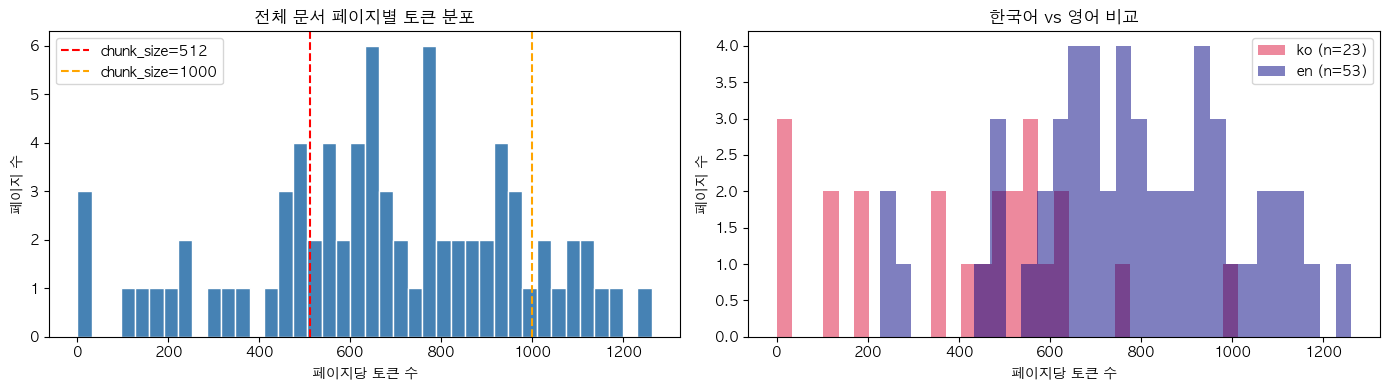

In [13]:
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (Windows / Mac 둘 다 시도)
for font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if any(font in f.name for f in matplotlib.font_manager.fontManager.ttflist):
        matplotlib.rcParams["font.family"] = font
        break
matplotlib.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (좌) 전체 분포
axes[0].hist(df_tokens["tokens"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(512, color="red", linestyle="--", label="chunk_size=512")
axes[0].axvline(1000, color="orange", linestyle="--", label="chunk_size=1000")
axes[0].set_xlabel("페이지당 토큰 수")
axes[0].set_ylabel("페이지 수")
axes[0].set_title("전체 문서 페이지별 토큰 분포")
axes[0].legend()

# (우) 언어별 비교
for lang, color in [("ko", "crimson"), ("en", "navy")]:
    sub = df_tokens[df_tokens["language"] == lang]["tokens"]
    if len(sub):
        axes[1].hist(
            sub, bins=30, alpha=0.5, label=f"{lang} (n={len(sub)})", color=color
        )
axes[1].set_xlabel("페이지당 토큰 수")
axes[1].set_ylabel("페이지 수")
axes[1].set_title("한국어 vs 영어 비교")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    DATA_PROCESSED / "week4_token_distribution.png", dpi=120, bbox_inches="tight"
)
plt.show()

## 시각화 2 — 문서별 페이지 토큰 박스플롯

/var/folders/mn/yfz483xx7vb96q21lp6w55gm0000gn/T/ipykernel_77889/2906628120.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=False)


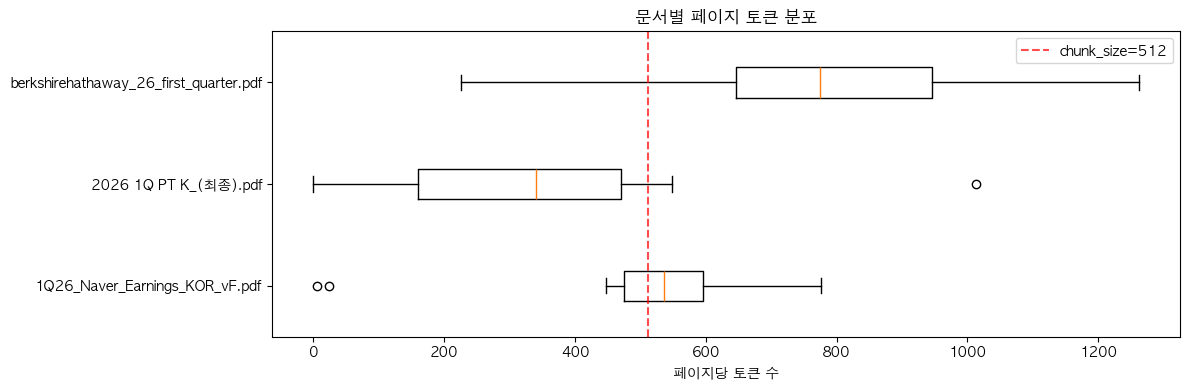

In [14]:
# 파일별 박스플롯 (긴 파일명은 줄임)
fig, ax = plt.subplots(figsize=(12, max(4, len(pdf_paths) * 0.4)))

data = []
labels = []
for fn, sub in df_tokens.groupby("filename"):
    data.append(sub["tokens"].tolist())
    short = fn if len(fn) <= 40 else fn[:37] + "..."
    labels.append(short)

ax.boxplot(data, labels=labels, vert=False)
ax.axvline(512, color="red", linestyle="--", alpha=0.7, label="chunk_size=512")
ax.set_xlabel("페이지당 토큰 수")
ax.set_title("문서별 페이지 토큰 분포")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "week4_token_boxplot.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. 구조적 특성 진단 (수동 확인용 샘플)

In [15]:
def find_image_heavy_pages(pdf_path: Path, top_n: int = 3) -> list:
    doc = fitz.open(str(pdf_path))
    page_info = []
    for i, page in enumerate(doc):
        img_count = len(page.get_images())
        text_len = len(page.get_text())
        page_info.append((i + 1, img_count, text_len))
    doc.close()
    page_info.sort(key=lambda x: x[1], reverse=True)
    return page_info[:top_n]


print("각 PDF의 이미지가 많은 페이지 top 3:")
for p in pdf_paths:
    heavy = find_image_heavy_pages(p)
    if heavy[0][1] > 0:
        print(f"\n{p.name}")
        for pg, imgs, chars in heavy:
            print(f"  p.{pg}: 이미지 {imgs}개 / 텍스트 {chars}자")

각 PDF의 이미지가 많은 페이지 top 3:

1Q26_Naver_Earnings_KOR_vF.pdf
  p.7: 이미지 2개 / 텍스트 685자
  p.1: 이미지 1개 / 텍스트 26자
  p.2: 이미지 1개 / 텍스트 480자

2026 1Q PT K_(최종).pdf
  p.1: 이미지 10개 / 텍스트 0자
  p.6: 이미지 3개 / 텍스트 499자
  p.2: 이미지 2개 / 텍스트 169자


## 6. 진단 요약 표 (retrospective용)
이 표를 그대로 docs/week4_retrospective.md에 옮기면 된다.

In [ ]:
# 최종 요약 테이블
summary = df_basic_with_noise.copy()

# 페이지당 평균 토큰 추가
tok_avg = (
    df_tokens.groupby("filename")["tokens"]
    .agg(["mean", "median", "max"])
    .round(0)
    .astype(int)
)
tok_avg.columns = ["avg_tokens_per_page", "median_tokens", "max_tokens"]
summary = summary.merge(tok_avg, on="filename", how="left")

# 노이즈 비율
# page_number_hits: 페이지 번호가 검출된 페이지 수. 예를 들어, 100페이지짜리 문서에서 50페이지 이상에서 페이지 번호 패턴이 감지되었다면 page_number_hits는 50이 된다.
# page_number_ratio: 전체 페이지 중 페이지 번호가 검출된 비율. 예를 들어, 100페이지짜리 문서에서 50페이지 이상에서 페이지 번호 패턴이 감지되었다면 page_number_ratio는 0.5가 된다.
# pages = 100 page_number_hits = 95 => page_number_ratio = 0.95 100페이지 중 95페이지에서 페이지 번호 패턴이 발견됨.
summary["page_number_ratio"] = (summary["page_number_hits"] / summary["pages"]).round(2)

summary_cols = [
    "filename",
    "org",
    "language",
    "pages",
    "avg_tokens_per_page",
    "median_tokens",
    "max_tokens",
    "images",
    "tables",
    "page_number_hits",
    "repeated_short_lines",
]
summary = summary[summary_cols]
summary.to_csv(
    DATA_PROCESSED / "week4_data_diagnosis.csv", index=False, encoding="utf-8-sig"
)
print(f"저장: {DATA_PROCESSED / 'week4_data_diagnosis.csv'}")
summary


저장: /Users/judy/Desktop/github/mo_du_yeon/Advanced-RAG-Multimodal-AI-Agent/data/processed/week4_data_diagnosis.csv


,filename,org,language,pages,avg_tokens_per_page,median_tokens,max_tokens,images,tables,page_number_hits,repeated_short_lines
0,1Q26_Naver_Earnings_KOR_vF.pdf,NAVER,ko,12,475,536,776,13,15,5,67
1,2026 1Q PT K_(최종).pdf,Kakao,ko,11,349,341,1013,31,7,22,51
2,berkshirehathaway_26_first_quarter.pdf,Berkshire Hathaway,en,53,784,775,1262,0,330,575,190


## 7. 전략별 진단 지표 분리
문서별로 Text Extraction, Chunking, Image/Chart, Table, Retrieval 전략을 판단하기 위한 지표를 분리한다.


In [ ]:
# 전략별 판단에 필요한 문서 단위 지표 만들기
# - df_basic_with_noise: 기본 텍스트/노이즈 지표
# - df_tokens: 페이지별 토큰 지표
# - df_images: 이미지 위치/크기 지표
# - df_tables: 테이블 위치/크기 지표

strategy_metrics = df_basic_with_noise.copy()

# 1) Text extraction 전략 지표
strategy_metrics["text_page_ratio"] = (
    strategy_metrics["pages_with_text"] / strategy_metrics["pages"].clip(lower=1)
).round(2)
strategy_metrics["chars_per_mb"] = (
    strategy_metrics["total_chars"] / strategy_metrics["file_size_mb"].replace(0, pd.NA)
).round(0)

# 2) Chunking 전략 지표
if "df_tokens" in globals() and not df_tokens.empty:
    token_stats = (
        df_tokens.groupby("filename")["tokens"]
        .agg(
            avg_tokens_per_page="mean",
            median_tokens_per_page="median",
            max_tokens_per_page="max",
            p90_tokens_per_page=lambda s: s.quantile(0.9),
        )
        .round(0)
        .reset_index()
    )
    strategy_metrics = strategy_metrics.merge(token_stats, on="filename", how="left")
else:
    for col in ["avg_tokens_per_page", "median_tokens_per_page", "max_tokens_per_page", "p90_tokens_per_page"]:
        strategy_metrics[col] = pd.NA

# 3) Image / chart 전략 지표
large_image_threshold = 0.10  # 페이지 면적의 10% 이상이면 의미 있는 시각 요소 후보로 본다.
if "df_images" in globals() and not df_images.empty:
    image_stats = (
        df_images.assign(is_large_image=df_images["area_ratio"] >= large_image_threshold)
        .groupby("filename")
        .agg(
            image_objects=("xref", "count"),
            image_pages=("page", "nunique"),
            large_images=("is_large_image", "sum"),
            max_image_area_ratio=("area_ratio", "max"),
        )
        .reset_index()
    )
    large_image_pages = (
        df_images[df_images["area_ratio"] >= large_image_threshold]
        .groupby("filename")["page"]
        .nunique()
        .rename("large_image_pages")
        .reset_index()
    )
    image_stats = image_stats.merge(large_image_pages, on="filename", how="left")
    strategy_metrics = strategy_metrics.merge(image_stats, on="filename", how="left")
else:
    for col in ["image_objects", "image_pages", "large_images", "large_image_pages", "max_image_area_ratio"]:
        strategy_metrics[col] = 0

# 4) Table 전략 지표
large_table_threshold = 0.10
if "df_tables" in globals() and not df_tables.empty:
    table_stats = (
        df_tables.assign(
            is_large_table=df_tables["area_ratio"] >= large_table_threshold,
            has_header=df_tables["header_candidate"].notna() & (df_tables["header_candidate"].str.len() > 0),
        )
        .groupby("filename")
        .agg(
            detected_tables=("table_index", "count"),
            table_pages=("page", "nunique"),
            large_tables=("is_large_table", "sum"),
            max_table_area_ratio=("area_ratio", "max"),
            tables_with_header=("has_header", "sum"),
        )
        .reset_index()
    )
    strategy_metrics = strategy_metrics.merge(table_stats, on="filename", how="left")
else:
    for col in ["detected_tables", "table_pages", "large_tables", "max_table_area_ratio", "tables_with_header"]:
        strategy_metrics[col] = 0

# 결측값 정리 및 파생 지표
count_cols = [
    "image_objects", "image_pages", "large_images", "large_image_pages",
    "detected_tables", "table_pages", "large_tables", "tables_with_header",
]
for col in count_cols:
    strategy_metrics[col] = strategy_metrics[col].fillna(0).astype(int)

for col in ["max_image_area_ratio", "max_table_area_ratio"]:
    strategy_metrics[col] = strategy_metrics[col].fillna(0).round(4)

strategy_metrics["large_image_page_ratio"] = (
    strategy_metrics["large_image_pages"] / strategy_metrics["pages"].clip(lower=1)
).round(2)
strategy_metrics["table_page_ratio"] = (
    strategy_metrics["table_pages"] / strategy_metrics["pages"].clip(lower=1)
).round(2)
# 페이지 번호가 전체 페이지 중 얼마나 자주 등장하는가
strategy_metrics["page_number_ratio"] = (
    strategy_metrics["page_number_hits"] /
    strategy_metrics["pages"].clip(lower=1)
).round(2)

strategy_metric_cols = [
    "filename", "org", "language", "doc_type", "pages",
    "text_page_ratio", "avg_chars_per_page", "chars_per_mb",
    "median_tokens_per_page", "p90_tokens_per_page", "max_tokens_per_page",
    "image_objects", "large_images", "large_image_page_ratio", "max_image_area_ratio",
    "detected_tables", "large_tables", "table_page_ratio", "max_table_area_ratio", "tables_with_header",
    "page_number_ratio", "repeated_short_lines",
]
# "page_number_ratio" 왜 누락? 이게 뭘 의미하는 지?
# print(strategy_metrics.columns.tolist())

# 빠진 cols 체크
missing_cols = [
    col for col in strategy_metric_cols
    if col not in strategy_metrics.columns
]

print("missing:", missing_cols)
print("available:", strategy_metrics.columns.tolist())

strategy_metrics = strategy_metrics[strategy_metric_cols]
strategy_metrics.to_csv(DATA_PROCESSED / "week4_strategy_metrics.csv", index=False, encoding="utf-8-sig")
print(f"저장: {DATA_PROCESSED / 'week4_strategy_metrics.csv'}")
strategy_metrics


['filename', 'org', 'language', 'doc_type', 'file_size_mb', 'pages', 'pages_with_text', 'total_chars', 'avg_chars_per_page', 'images', 'tables', 'page_number_hits', 'repeated_short_lines', 'text_page_ratio', 'chars_per_mb', 'avg_tokens_per_page', 'median_tokens_per_page', 'max_tokens_per_page', 'p90_tokens_per_page', 'image_objects', 'image_pages', 'large_images', 'max_image_area_ratio', 'large_image_pages', 'detected_tables', 'table_pages', 'large_tables', 'max_table_area_ratio', 'tables_with_header', 'large_image_page_ratio', 'table_page_ratio']
missing: []
available: ['filename', 'org', 'language', 'doc_type', 'file_size_mb', 'pages', 'pages_with_text', 'total_chars', 'avg_chars_per_page', 'images', 'tables', 'page_number_hits', 'repeated_short_lines', 'text_page_ratio', 'chars_per_mb', 'avg_tokens_per_page', 'median_tokens_per_page', 'max_tokens_per_page', 'p90_tokens_per_page', 'image_objects', 'image_pages', 'large_images', 'max_image_area_ratio', 'large_image_pages', 'detected_t

,filename,org,language,doc_type,pages,text_page_ratio,avg_chars_per_page,chars_per_mb,median_tokens_per_page,p90_tokens_per_page,...,image_objects,large_images,large_image_page_ratio,max_image_area_ratio,detected_tables,large_tables,table_page_ratio,max_table_area_ratio,tables_with_header,repeated_short_lines
0,1Q26_Naver_Earnings_KOR_vF.pdf,NAVER,ko,earnings_report,12,1.00,537,29282.0,536.0,632.0,...,14,0,0.00,0.0045,15,7,0.67,0.5665,15,67
1,2026 1Q PT K_(최종).pdf,Kakao,ko,earnings_presentation,11,0.91,432,6011.0,341.0,549.0,...,31,1,0.09,0.1032,7,2,0.27,0.6467,3,51
2,berkshirehathaway_26_first_quarter.pdf,Berkshire Hathaway,en,quarterly_report,53,1.00,3262,146526.0,775.0,1091.0,...,0,0,0.00,0.0000,330,57,0.96,0.6555,330,190


## 8. 문서별 아키텍처 추천
위에서 분리한 지표를 기준으로 문서별 처리 전략을 추천한다.


In [24]:
def choose_text_extraction(row):
    if row["text_page_ratio"] < 0.8:
        return "OCR + layout-aware extraction"
    if row["avg_chars_per_page"] < 200 and row["large_image_page_ratio"] >= 0.2:
        return "Native text + image/chart captioning"
    return "Native PDF text extraction"


def choose_chunking(row):
    doc_type = str(row.get("doc_type", ""))
    median_tokens = row.get("median_tokens_per_page")
    max_tokens = row.get("max_tokens_per_page")

    if "presentation" in doc_type:
        return "Slide/page-aware chunking"
    if pd.notna(max_tokens) and max_tokens >= 1500:
        return "Recursive text chunking + section metadata"
    if pd.notna(median_tokens) and median_tokens <= 700:
        return "Page-as-chunk + metadata"
    return "Page split + recursive chunking"


def choose_image_strategy(row):
    if row["large_image_page_ratio"] >= 0.2 or row["max_image_area_ratio"] >= 0.25:
        return "Image/chart caption chunks + page screenshots"
    if row["image_objects"] >= 20 and row["large_images"] == 0:
        return "Ignore tiny decorative images"
    return "Text-first; keep image metadata only"


def choose_table_strategy(row):
    if row["table_page_ratio"] >= 0.2 or row["large_tables"] > 0:
        return "Extract tables as Markdown/CSV chunks"
    if row["detected_tables"] > 0:
        return "Store table snippets with page metadata"
    return "No separate table index needed"


def choose_retrieval_strategy(row):
    needs_visual = "caption" in choose_image_strategy(row).lower()
    needs_table = "table" in choose_table_strategy(row).lower() or "Markdown" in choose_table_strategy(row)
    # 페이지 번호가 절반 이상 페이지에 등장하거나 반복되는 짧은 줄(헤더/푸터)이 많으면 문서 노이즈가 많다고 판단
    # page_number_ratio 제외 -> 페이지 번호가 본문 텍스트에 포함되어 추출되는 구조가 아님. metadata로 잘 분리되어 있음.
    # row["page_number_ratio"] >= 0.5 는 페이지 번호가 전체 페이지의 절반 이상에서 발견된다는 뜻. 예를 들어, 100페이지짜리 문서에서 50페이지 이상에서 페이지 번호 패턴이 감지되었다면 page_number_ratio는 0.5 이상이 된다. 
    noisy = row["repeated_short_lines"] >= 10

    if needs_visual or needs_table:
        return "Hybrid retrieval + reranker + metadata filters"
    if noisy:
        return "Vector retrieval + noise-cleaned chunks"
    return "Vector retrieval + metadata filters"


architecture_by_doc = strategy_metrics.copy()
architecture_by_doc["text_extraction_architecture"] = architecture_by_doc.apply(choose_text_extraction, axis=1)
architecture_by_doc["chunking_strategy"] = architecture_by_doc.apply(choose_chunking, axis=1)
architecture_by_doc["image_chart_strategy"] = architecture_by_doc.apply(choose_image_strategy, axis=1)
architecture_by_doc["table_strategy"] = architecture_by_doc.apply(choose_table_strategy, axis=1)
architecture_by_doc["retrieval_strategy"] = architecture_by_doc.apply(choose_retrieval_strategy, axis=1)

architecture_cols = [
    "filename", "doc_type", "language",
    "text_extraction_architecture", "chunking_strategy",
    "image_chart_strategy", "table_strategy", "retrieval_strategy",
]
architecture_by_doc = architecture_by_doc[architecture_cols]
architecture_by_doc.to_csv(DATA_PROCESSED / "week4_architecture_by_doc.csv", index=False, encoding="utf-8-sig")
print(f"저장: {DATA_PROCESSED / 'week4_architecture_by_doc.csv'}")
architecture_by_doc


저장: /Users/judy/Desktop/github/mo_du_yeon/Advanced-RAG-Multimodal-AI-Agent/data/processed/week4_architecture_by_doc.csv


,filename,doc_type,language,text_extraction_architecture,chunking_strategy,image_chart_strategy,table_strategy,retrieval_strategy
0,1Q26_Naver_Earnings_KOR_vF.pdf,earnings_report,ko,Native PDF text extraction,Page-as-chunk + metadata,Text-first; keep image metadata only,Extract tables as Markdown/CSV chunks,Hybrid retrieval + reranker + metadata filters
1,2026 1Q PT K_(최종).pdf,earnings_presentation,ko,Native PDF text extraction,Slide/page-aware chunking,Text-first; keep image metadata only,Extract tables as Markdown/CSV chunks,Hybrid retrieval + reranker + metadata filters
2,berkshirehathaway_26_first_quarter.pdf,quarterly_report,en,Native PDF text extraction,Page split + recursive chunking,Text-first; keep image metadata only,Extract tables as Markdown/CSV chunks,Hybrid retrieval + reranker + metadata filters


## 9. 최종 아키텍처 판단 표
전략별로 어떤 지표를 보고, 어떤 기준이면 어떤 아키텍처를 선택할지 한눈에 정리한다.
### 코퍼스 전체 관찰값이란?
수집한 모든 문서를 분석해 보니 어떤 특징들이 보였는지 요약한 통계
: 전체 PDF를 하나의 코퍼스로 보고 요약 판단한 표.


In [30]:
# 코퍼스 전체 관찰값 요약
corpus = {
    "docs": len(strategy_metrics),
    "languages": ", ".join(sorted(strategy_metrics["language"].dropna().astype(str).unique())),
    "doc_types": ", ".join(sorted(strategy_metrics["doc_type"].dropna().astype(str).unique())),
    "min_text_page_ratio": strategy_metrics["text_page_ratio"].min(),
    "median_avg_chars_per_page": strategy_metrics["avg_chars_per_page"].median(),
    "median_tokens_per_page": strategy_metrics["median_tokens_per_page"].median(),
    "max_tokens_per_page": strategy_metrics["max_tokens_per_page"].max(),
    "max_large_image_page_ratio": strategy_metrics["large_image_page_ratio"].max(),
    "max_table_page_ratio": strategy_metrics["table_page_ratio"].max(),
    # "max_page_number_ratio": strategy_metrics["page_number_ratio"].max(), # PDF 중 가장 페이지 번호 패턴이 자주 등장하는 문서의 비율
}


def yes_no(condition):
    return "필요" if condition else "낮음"

architecture_decision_table = pd.DataFrame([
    {
        "strategy": "Text extraction / OCR",
        "metrics_to_check": "text_page_ratio, avg_chars_per_page, chars_per_mb",
        "observed": f"min text_page_ratio={corpus['min_text_page_ratio']}, median avg_chars/page={corpus['median_avg_chars_per_page']:.0f}",
        "decision_rule": "text_page_ratio < 0.8 또는 avg_chars/page < 200이면 OCR/layout 보강",
        "recommended_architecture": (
            "OCR + layout-aware extraction"
            if corpus["min_text_page_ratio"] < 0.8 or corpus["median_avg_chars_per_page"] < 200
            else "Native PDF text extraction 중심"
        ),
    },
    {
        "strategy": "Chunking",
        "metrics_to_check": "median_tokens_per_page, p90_tokens_per_page, max_tokens_per_page, doc_type",
        "observed": f"median tokens/page={corpus['median_tokens_per_page']:.0f}, max tokens/page={corpus['max_tokens_per_page']:.0f}",
        "decision_rule": "발표자료는 page/slide 단위, max_tokens >= 1500이면 recursive chunking",
        "recommended_architecture": (
            "Slide/page-aware + recursive chunking 혼합"
            if corpus["max_tokens_per_page"] >= 1500
            else "Page-as-chunk + metadata"
        ),
    },
    {
        "strategy": "Image / chart handling",
        "metrics_to_check": "large_image_page_ratio, max_image_area_ratio, image_objects",
        "observed": f"max large_image_page_ratio={corpus['max_large_image_page_ratio']}",
        "decision_rule": "large_image_page_ratio >= 0.2 또는 max_image_area_ratio >= 0.25이면 chart/image caption 필요",
        "recommended_architecture": (
            "Image/chart caption chunks + page screenshot 보존"
            if (strategy_metrics["large_image_page_ratio"].ge(0.2).any() or strategy_metrics["max_image_area_ratio"].ge(0.25).any())
            else "텍스트 중심, 이미지는 metadata만 보존"
        ),
    },
    {
        "strategy": "Table handling",
        "metrics_to_check": "table_page_ratio, detected_tables, large_tables, tables_with_header",
        "observed": f"max table_page_ratio={corpus['max_table_page_ratio']}",
        "decision_rule": "table_page_ratio >= 0.2 또는 large_tables > 0이면 표를 별도 chunk/index로 저장",
        "recommended_architecture": (
            "Table extraction → Markdown/CSV chunks → table-aware retrieval"
            if (strategy_metrics["table_page_ratio"].ge(0.2).any() or strategy_metrics["large_tables"].gt(0).any())
            else "일반 텍스트 chunk 안에 표 텍스트 포함"
        ),
    },
    {
        "strategy": "Retrieval",
        "metrics_to_check": "language, doc_type, visual/table 필요 여부,repeated_short_lines", # page_number_ratio 제거
        "observed": f"languages={corpus['languages']}, doc_types={corpus['doc_types']}", # , max page_number_ratio={corpus['max_page_number_ratio']}" 제거
        "decision_rule": "문서 타입/언어가 섞이고 표/차트가 중요하면 hybrid + reranker + metadata filter",
        "recommended_architecture": "Hybrid search(BM25+Vector) + reranker + filename/org/page/doc_type metadata filter",
    },
    {
        "strategy": "Citation / grounding",
        "metrics_to_check": "filename, org, page, doc_type, table/image bbox",
        "observed": f"docs={corpus['docs']}",
        "decision_rule": "재무 문서는 출처 페이지와 표/차트 위치를 답변에 함께 반환",
        "recommended_architecture": "Chunk metadata에 filename/org/page/section_type/bbox 저장 + answer citation",
    },
])

architecture_decision_table.to_csv(
    DATA_PROCESSED / "week4_architecture_decision_table.csv",
    index=False,
    encoding="utf-8-sig",
)
print(f"저장: {DATA_PROCESSED / 'week4_architecture_decision_table.csv'}")
architecture_decision_table


저장: /Users/judy/Desktop/github/mo_du_yeon/Advanced-RAG-Multimodal-AI-Agent/data/processed/week4_architecture_decision_table.csv


,strategy,metrics_to_check,observed,decision_rule,recommended_architecture
0,Text extraction / OCR,"text_page_ratio, avg_chars_per_page, chars_per_mb","min text_page_ratio=0.91, median avg_chars/pag...",text_page_ratio < 0.8 또는 avg_chars/page < 200이...,Native PDF text extraction 중심
1,Chunking,"median_tokens_per_page, p90_tokens_per_page, m...","median tokens/page=536, max tokens/page=1262","발표자료는 page/slide 단위, max_tokens >= 1500이면 recu...",Page-as-chunk + metadata
2,Image / chart handling,"large_image_page_ratio, max_image_area_ratio, ...",max large_image_page_ratio=0.09,large_image_page_ratio >= 0.2 또는 max_image_are...,"텍스트 중심, 이미지는 metadata만 보존"
3,Table handling,"table_page_ratio, detected_tables, large_table...",max table_page_ratio=0.96,table_page_ratio >= 0.2 또는 large_tables > 0이면 ...,Table extraction → Markdown/CSV chunks → table...
4,Retrieval,"language, doc_type, visual/table 필요 여부,repeate...","languages=en, ko, doc_types=earnings_presentat...",문서 타입/언어가 섞이고 표/차트가 중요하면 hybrid + reranker + m...,Hybrid search(BM25+Vector) + reranker + filena...
5,Citation / grounding,"filename, org, page, doc_type, table/image bbox",docs=3,재무 문서는 출처 페이지와 표/차트 위치를 답변에 함께 반환,Chunk metadata에 filename/org/page/section_type...
